In this lab/demo, we will conduct a brief exploratory data analysis of our data, train a logistic regression, and compute different selection metrics.

Human Activity Recognition data set, which contains mobile sensor data, and a label of a specific human activity (sitting, standing, walking upstairs, downstairs, etc.) at the time of those sensors readings.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import requests

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Human_Activity_Recognition_Using_Smartphones_Data.csv"
filename = "human_activity_data.csv"

In [3]:
response = requests.get(url)
with open(filename, "wb") as f:
    f.write(response.content)

print("Done! The file is now saved on your computer.")

Done! The file is now saved on your computer.


In [4]:
data = pd.read_csv(filename)
print(f"Dataset loaded successfully with shape: {data.shape}")
data.head()

Dataset loaded successfully with shape: (10299, 562)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


In [5]:
data.dtypes

tBodyAcc-mean()-X                       float64
tBodyAcc-mean()-Y                       float64
tBodyAcc-mean()-Z                       float64
tBodyAcc-std()-X                        float64
tBodyAcc-std()-Y                        float64
                                         ...   
angle(tBodyGyroJerkMean,gravityMean)    float64
angle(X,gravityMean)                    float64
angle(Y,gravityMean)                    float64
angle(Z,gravityMean)                    float64
Activity                                 object
Length: 562, dtype: object

## Data scaling 
from -1 (minimum) to 1.0 (maximum) here data is already scaled
Since the sensors in a smartphone (accelerometer/gyroscope) often record both positive and negative physical movement, the $[-1, 1]$ range is a very natural fit for this specific dataset.

# FEATUE SCALING
It ensures that features with larger raw numbers (like total accn) don't overpower features with smaller number during 
#### Gradient Descent

In [6]:
data.iloc[:, :-1].min().value_counts()

-1.0    561
Name: count, dtype: int64

In [7]:
data.iloc[:, :-1].max().value_counts()

1.0    561
Name: count, dtype: int64

In [8]:
data.Activity.value_counts()

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

## Encoding (Label Encoding / One-Hot Encoding): 
This is used for Categorical data (strings like "Walking"). It’s the process of turning "words" into "numbers" because machine learning models are essentially big calculators—they can't do math on the word "Laying," but they can on the number 0.

Scikit learn classifiers won't accept a sparse matrix for the prediction column. LabelEncoder needs to be used to convert the activity labels to integers

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Activity'] = le.fit_transform(data.Activity)
data['Activity'].sample(10) #Looking at 10 random values
print(list(le.classes_))

['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


## Correlations calculation between independent variables


In [10]:
## Calculate the correlation values
feature_cols = data.columns[:-1]
corr_values = data[feature_cols].corr()
corr_values

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
tBodyAcc-mean()-X,1.000000,0.128037,-0.230302,0.004590,-0.016785,-0.036071,0.010303,-0.017488,-0.038805,0.046943,...,0.029901,-0.006179,-0.002255,-0.552989,0.015754,0.036047,0.034296,-0.041021,0.034053,0.030656
tBodyAcc-mean()-Y,0.128037,1.000000,-0.029882,-0.046352,-0.046996,-0.054153,-0.045247,-0.047673,-0.055524,-0.039445,...,-0.014402,-0.000649,-0.002842,0.077750,-0.027567,0.013241,0.077627,-0.007513,-0.005616,-0.016233
tBodyAcc-mean()-Z,-0.230302,-0.029882,1.000000,-0.024185,-0.023745,-0.015632,-0.022872,-0.022966,-0.009577,-0.040218,...,-0.015358,0.023050,0.023122,0.055020,-0.042083,-0.066233,-0.030748,0.003215,-0.012986,-0.028406
tBodyAcc-std()-X,0.004590,-0.046352,-0.024185,1.000000,0.922525,0.861910,0.998662,0.916087,0.856497,0.981226,...,-0.068807,0.165552,0.135171,-0.034334,-0.017096,0.027464,-0.027123,-0.374104,0.449425,0.393063
tBodyAcc-std()-Y,-0.016785,-0.046996,-0.023745,0.922525,1.000000,0.888259,0.918561,0.997510,0.887052,0.911137,...,-0.109941,0.220279,0.191164,-0.020806,-0.006605,0.001902,-0.015784,-0.381391,0.506106,0.425511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"angle(tBodyGyroMean,gravityMean)",0.036047,0.013241,-0.066233,0.027464,0.001902,-0.004984,0.027729,-0.002924,-0.009873,0.033533,...,-0.029273,0.042123,0.035684,-0.013009,0.010679,1.000000,-0.112454,-0.007095,-0.006444,-0.015380
"angle(tBodyGyroJerkMean,gravityMean)",0.034296,0.077627,-0.030748,-0.027123,-0.015784,-0.012196,-0.027097,-0.013411,-0.012800,-0.030908,...,-0.002618,-0.013065,-0.011829,-0.027478,0.023605,-0.112454,1.000000,0.024822,-0.004582,-0.012549
"angle(X,gravityMean)",-0.041021,-0.007513,0.003215,-0.374104,-0.381391,-0.353271,-0.371168,-0.378013,-0.355836,-0.384244,...,0.087571,-0.085226,-0.081971,0.008050,0.017534,-0.007095,0.024822,1.000000,-0.748249,-0.635231
"angle(Y,gravityMean)",0.034053,-0.005616,-0.012986,0.449425,0.506106,0.459092,0.444926,0.507947,0.460345,0.458832,...,-0.105752,0.087671,0.078010,0.003082,-0.007256,-0.006444,-0.004582,-0.748249,1.000000,0.545614




 ## Triangular Lower Indices (tril)
a correlation matrix: it is symmetric. The correlation between Feature A and Feature B is exactly the same as the correlation between Feature B and Feature A. Also, the diagonal is always 1.0 (because every feature is perfectly correlated with itself).

In [11]:
tril_index = np.tril_indices_from(corr_values)
tril_index
#gives you the "coordinates" (row and column numbers) for the lower half of that giant square.

(array([  0,   1,   1, ..., 560, 560, 560]),
 array([  0,   0,   1, ..., 558, 559, 560]))

Tuple of two numpy arrays

it is in the parallel array format above array for row and below for column like in the above coordinates will be like
(0,0) (1,0) (1,1),....,(560,558), (560,559), (560,560)


Logistic Regression works by assigning a "weight" (coefficient) to each feature. If two features are highly correlated (e.g., $r > 0.95$), it means they are telling the model the exact same thing.
We calculate the correlation matrix to find these "twin" features. If we find two features with a correlation of 0.99, we drop one of them.
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$
Here using it to solve Multicollinearity

In [12]:
# Make the unused values NaNs
for coord in zip(*tril_index): # '*' Unpacking operator
    corr_values.iloc[coord[0], coord[1]] = np.nan
#nan (Not a number/empty)


When we write zip(*tril_index), Python does this:

Unpacks it: It turns that one tuple into two separate lists being handed to zip.

Equivalent to: zip([row0, row1, row2], [col0, col1, col2])

zip pairs them: It grabs row0 and col0 and makes a pair, then row1 and col1, and so on.

This turns your "Parallel Arrays" back into "Coordinate Pairs" like (0,0), (1,0), etc.
Pair is a tuple 
##### zip(*list_of_lists): A common trick to "transpose" or "un-parallelize" data.

In [13]:

# Stack the data and convert to a data frame
#.stack() takes 2D matrix and crushes it into 1D listin Pandas
#also .stack() ignores nan by default 
#a clean DataFrame with 3 columns feature1, feature2, correlation i
corr_values = (corr_values
               .stack()
               .to_frame()
               .reset_index()
               .rename(columns={'level_0':'feature1',
                                'level_1':'feature2',
                                0:'correlation'}))

# Get the absolute values for sorting
corr_values['abs_correlation'] = corr_values.correlation.abs()
# adding a new column abs_correlation
corr_values

,feature1,feature2,correlation,abs_correlation
0,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,0.128037,0.128037
1,tBodyAcc-mean()-X,tBodyAcc-mean()-Z,-0.230302,0.230302
2,tBodyAcc-mean()-X,tBodyAcc-std()-X,0.004590,0.004590
3,tBodyAcc-mean()-X,tBodyAcc-std()-Y,-0.016785,0.016785
4,tBodyAcc-mean()-X,tBodyAcc-std()-Z,-0.036071,0.036071
...,...,...,...,...
157075,"angle(tBodyGyroJerkMean,gravityMean)","angle(Y,gravityMean)",-0.004582,0.004582
157076,"angle(tBodyGyroJerkMean,gravityMean)","angle(Z,gravityMean)",-0.012549,0.012549
157077,"angle(X,gravityMean)","angle(Y,gravityMean)",-0.748249,0.748249
157078,"angle(X,gravityMean)","angle(Z,gravityMean)",-0.635231,0.635231


###### EDA

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

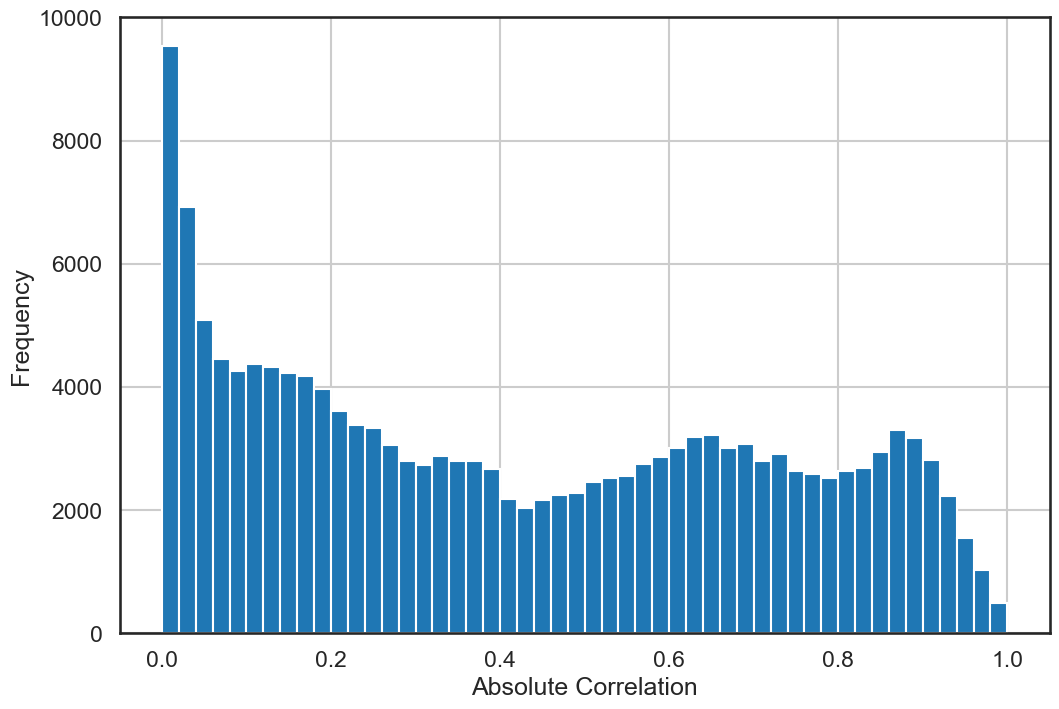

In [15]:
sns.set_context('talk')
sns.set_style('white')

ax = corr_values.abs_correlation.hist(bins=50, figsize=(12, 8))
ax.set(xlabel='Absolute Correlation', ylabel='Frequency'); #In Jupyter, adding a semicolon at the end of a plotting command prevents Python from printing out the text "address" of the object (like <Axes: xlabel='Absolute Correlation'>).
plt.show()

In [16]:
# The most highly correlated values
corr_values.sort_values('correlation', ascending=False).query('abs_correlation>0.8')


,feature1,feature2,correlation,abs_correlation
156894,fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-sma(),1.000000,1.000000
93902,tBodyAccMag-sma(),tGravityAccMag-sma(),1.000000,1.000000
101139,tBodyAccJerkMag-mean(),tBodyAccJerkMag-sma(),1.000000,1.000000
96706,tGravityAccMag-mean(),tGravityAccMag-sma(),1.000000,1.000000
94257,tBodyAccMag-energy(),tGravityAccMag-energy(),1.000000,1.000000
...,...,...,...,...
22657,tGravityAcc-mean()-Y,"angle(Y,gravityMean)",-0.993425,0.993425
39225,"tGravityAcc-arCoeff()-Z,3","tGravityAcc-arCoeff()-Z,4",-0.994267,0.994267
38739,"tGravityAcc-arCoeff()-Z,2","tGravityAcc-arCoeff()-Z,3",-0.994628,0.994628
23176,tGravityAcc-mean()-Z,"angle(Z,gravityMean)",-0.994764,0.994764


##### MODEL EVALUATION PHASE
Splitting Data set
Method we are using is Scikit-learn's StratifiedShuffleSplit : to maintain the same ratio of predictor classes

#### Stratification
###### Stratified splitting : 
  forces the split to maintain the original ratio of classes in test and train data set

In [17]:

from sklearn.model_selection import StratifiedShuffleSplit

# Get the split indexes
strat_shuf_split = StratifiedShuffleSplit(n_splits=1, 
                                          test_size=0.3, 
                                          random_state=42)
#random_state (like 42).It ensures that every time anyone runs this notebook, they get the exact same split. This makes our results "Reproducible."

train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))
# train_idx and test_idx both are numpy arrays

# Create the dataframes
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'Activity']

X_test  = data.loc[test_idx, feature_cols]
y_test  = data.loc[test_idx, 'Activity']

In [18]:
y_train.value_counts(normalize=True) #value_counts() counts how many of each activity are in the set.

#normalize=True converts those counts into percentages (decimals).

Activity
0    0.188792
2    0.185046
1    0.172562
3    0.167152
5    0.149951
4    0.136496
Name: proportion, dtype: float64

In [19]:
y_test.value_counts(normalize=True)

Activity
0    0.188673
2    0.185113
1    0.172492
3    0.167314
5    0.149838
4    0.136570
Name: proportion, dtype: float64

## Fitting a logistic regression model without any regularization using all of the features. Fitting a multi classs model
(Training model)

In the standard LogisticRegression class, Scikit-Learn is smart—it sees liblinear + 6 classes and automatically runs a  
##### One-vs-Rest 
strategy.

In [20]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='liblinear').fit(X_train, y_train)
# It uses the "simplest" settings to try and find a relationship between the 561 sensor readings and the 6 activities..fit(X_train, y_train): This is the universal command in Scikit-Learn. It tells the model: "Here are the features ($X$) and here are the correct answers ($y$). Go find the math (weights) that connects them.
#lr is Estimator object (trained models with saved weights inside them)

##### CV cross-validation
Smart model
The Problem: How do you know if your regularization strength ($C$) is the best one?
The Solution: Instead of we guessing, the model guesses for us! It splits our training data into 4 pieces (cv=4), trains on 3, tests on 1, and repeats this for 10 different strengths (Cs=10). It then automatically picks the "winner."

In [21]:

from sklearn.linear_model import LogisticRegressionCV
lr_l1 = LogisticRegressionCV(Cs=10, cv=4, penalty='l1', solver='liblinear').fit(X_train, y_train)

penalty='l1'	Lasso Regression. It can force some feature weights to exactly zero.
penalty='l2'	Ridge Regression. It keeps all weights small but non-zero.

In [22]:
lr_l2 = LogisticRegressionCV(Cs=10, cv=4, penalty='l2', solver='liblinear').fit(X_train, y_train)

#### Comparison table
Since we have 561 features and 6 classes, each model actually learned 3,366 weights ($561 \times 6$). Comparing those manually is impossible, so this code builds a master spreadsheet to see them all at once
 By looking at these table we can compare 
 e.g. 
 Does the L1 model have a 0.0 for this sensor (meaning it ignored it)?

Is the weight for the L2 model much smaller than the standard LR model?

In [23]:

coefficients = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]
#coef_ is the NumPy array containing all those $w$ (weights/coefficients) the model just learned during the .fit() process.
#Shape: It is a 2D array: (number_of_classes, number_of_features)
for lab,mod in zip(coeff_labels, coeff_models):
    coeffs = mod.coef_ 
    
    coeff_label = pd.MultiIndex(levels=[[lab], [0,1,2,3,4,5]], 
                                 codes=[[0,0,0,0,0,0], [0,1,2,3,4,5]])
    coefficients.append(pd.DataFrame(coeffs.T, columns=coeff_label))

coefficients = pd.concat(coefficients, axis=1) 
#axis=0 would stack the DataFrames on top of each other (making the table very long).

#axis=1 sticks them side-by-side.

coefficients.sample(10) #picks 10 random sensors

lr                                                     l1  \
            0         1         2         3         4         5    0   
233 -0.046577 -0.059748 -0.283639  0.445112  0.563015 -1.140558  0.0   
11   0.031034  0.096661 -0.100896 -0.334615 -0.237446  0.731150  0.0   
33   0.031591 -0.449316  0.116962 -0.130071 -0.132161 -0.596385  0.0   
356 -0.016990  0.099925  0.128752  0.473281 -0.206364  0.225821  0.0   
7   -0.044016 -0.005861 -0.435470  0.246578 -0.433986 -0.090402  0.0   
119 -0.147098  0.185357 -0.005479  0.746942 -1.021886  0.221864  0.0   
556 -0.022132 -0.659469  0.550630 -0.234910  0.385178 -0.351492  0.0   
27   0.084459  0.381895 -0.405315  0.573416 -0.541729  0.259296  0.0   
450  0.117520  0.106800 -0.049856  1.519651 -0.136011 -1.264013  0.0   
425 -0.040712 -0.215518 -0.008237 -0.256805 -0.132984  0.061965  0.0   

                                                             l2            \
            1         2         3         4         5         0         1   
233  0.000000  0.000000  0.000000  1.349581 -2.095235 -0.082521  0.116461   
11   0.000000  0.000000  0.000000  0.000000  2.252092  0.055703 -0.552473   
33  -1.162262  0.051178  0.000000  0.000000 -2.119254  0.020095 -2.331905   
356  0.000000  0.000000  0.719176 -0.380531  0.159801 -0.041115  1.016869   
7    0.000000 -1.398916  0.000000 -0.158360 -0.859295 -0.032279  0.804747   
119  0.000000  0.000000  0.777533 -1.788227  0.445736 -0.296800  0.039050   
556 -0.763863  0.487404 -0.095583  0.469435 -0.730346 -0.142627 -0.822697   
27   0.944295 -0.238382  0.000000 -0.629349  0.000000  0.218854  3.188264   
450  0.000000  0.104378  3.212710 -0.109935 -1.145129  0.142141 -0.288746   
425  0.000000  0.000000  0.000000  0.000000  0.000000 -0.059609 -1.649018   

                                             
            2         3         4         5  
233 -0.434235  1.295009  2.156510 -2.338835  
11  -0.145612 -0.909471 -0.602427  1.733717  
33   0.254702 -0.195753 -0.287312 -1.164165  
356  0.139353  1.907409 -0.827721 -0.049004  
7   -0.660762  0.771262 -1.098573 -0.401620  
119  0.059534  2.741478 -3.328984  0.540299  
556  0.584624 -0.632103  1.140235 -0.623892  
27  -0.891541  1.714480 -1.897721  0.472049  
450 -0.046039  3.507345 -1.121806 -1.864739  
425  0.154591 -0.783350 -0.832056  0.135007

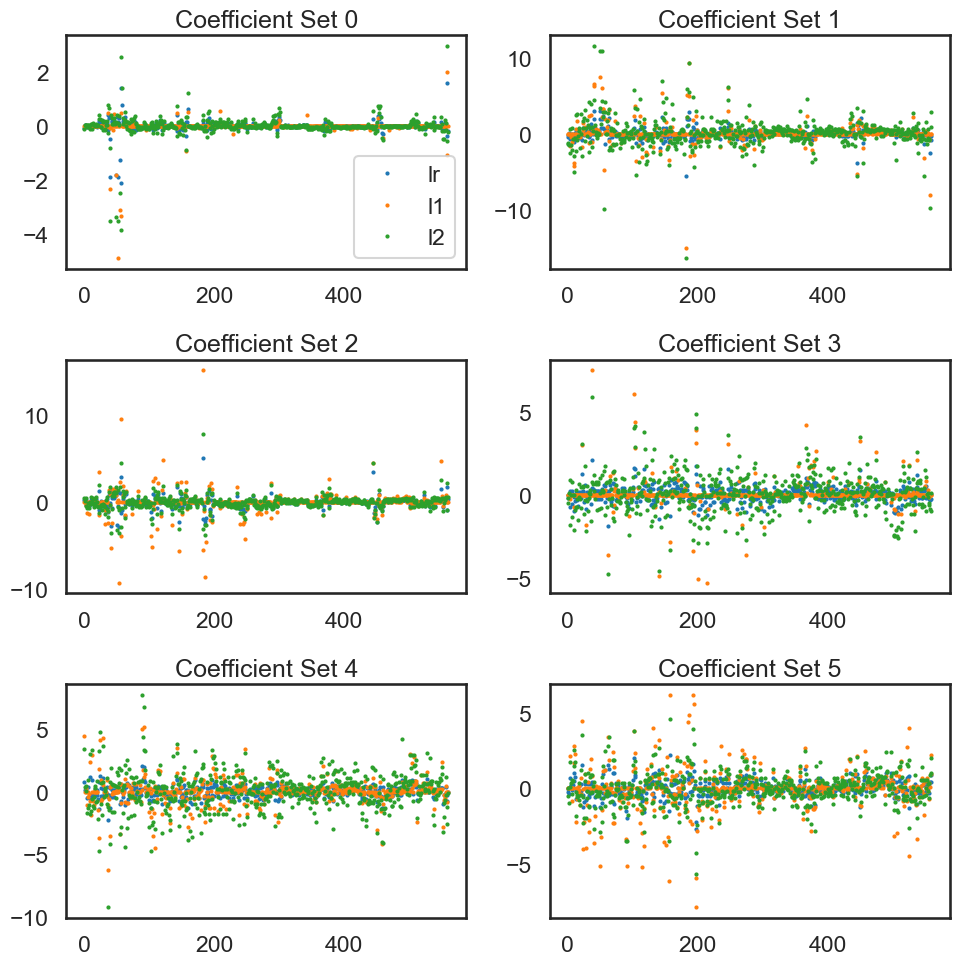

In [24]:
fig, axList = plt.subplots(nrows=3, ncols=2)
axList = axList.flatten()
fig.set_size_inches(10,10)

for ax in enumerate(axList):
    loc = ax[0]
    ax = ax[1]
    
    data = coefficients.xs(loc, level=1, axis=1)
    data.plot(marker='o', ls='', ms=2.0, ax=ax, legend=False)
    
    if ax is axList[0]:
        ax.legend(loc=4)
        
    ax.set(title='Coefficient Set '+str(loc))

plt.tight_layout()
plt.show()

Positive Weight: As this sensor value goes up, the probability of the activity goes up.

Negative Weight: As this sensor value goes up, the probability of the activity goes down
Identify the Spikes: In any plot, the features with the highest (positive or negative) dots are the sensors that define that activity.

Compare the Density: Notice how the orange dots (L1) are often missing or at zero? That’s L1 telling you, "I don't need these 400 sensors to tell if someone is sitting; I only need these 10."

Check for Stability: If you see the blue dots (lr) jumping to huge values (like +10 or -10) while the others stay small, it means the standard model is being too aggressive and might fail on new, unseen data.

In [25]:
# Predict the class and the probability for each
#Inference phase
y_pred = list()
y_prob = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab,mod in zip(coeff_labels, coeff_models):
    y_pred.append(pd.Series(mod.predict(X_test), name=lab))
    y_prob.append(pd.Series(mod.predict_proba(X_test).max(axis=1), name=lab))
    
y_pred = pd.concat(y_pred, axis=1)
y_prob = pd.concat(y_prob, axis=1)

y_pred.head() #predict activity index

,lr,l1,l2
0,3,3,3
1,5,5,5
2,3,3,3
3,1,1,1
4,0,0,0


Calculate Probabilities: It looks at a row of sensor data and says: "I think there's an 80% chance this is SITTING, a 15% chance it's STANDING, and a 5% chance it's other stuff."

Make a Decision: It picks the activity with the highest percentage.

In [26]:
y_prob.head() #how confident each model is in its answer

,lr,l1,l2
0,0.998939,0.998923,0.999757
1,0.988165,0.999568,0.999998
2,0.987592,0.995420,0.999907
3,0.981381,0.999189,0.994338
4,0.998277,0.999922,0.999997


In [27]:
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

metrics = list()
cm = dict()

for lab in coeff_labels:

    # Preciision, recall, f-score from the multi-class support function
    precision, recall, fscore, _ = score(y_test, y_pred[lab], average='weighted')
    
    # The usual way to calculate accuracy
    accuracy = accuracy_score(y_test, y_pred[lab])
    
    # ROC-AUC scores can be calculated by binarizing the data
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3,4,5]),
              label_binarize(y_pred[lab], classes=[0,1,2,3,4,5]), 
              average='weighted')
    
    # Last, the confusion matrix
    cm[lab] = confusion_matrix(y_test, y_pred[lab])
    
    metrics.append(pd.Series({'precision':precision, 'recall':recall, 
                              'fscore':fscore, 'accuracy':accuracy,
                              'auc':auc}, 
                             name=lab))

metrics = pd.concat(metrics, axis=1)

In [28]:
metrics

,lr,l1,l2
precision,0.984144,0.983514,0.984148
recall,0.984142,0.983495,0.984142
fscore,0.984143,0.983492,0.984143
accuracy,0.984142,0.983495,0.984142
auc,0.990384,0.989949,0.990352


While the Standard and L2 models achieved a peak accuracy of 98.4%, the L1 (Lasso) model provided the most robust solution. By performing automatic feature selection, it maintained a 98.3% accuracy while significantly reducing model complexity, making it ideal for deployment on resource-constrained devices like smartphones.

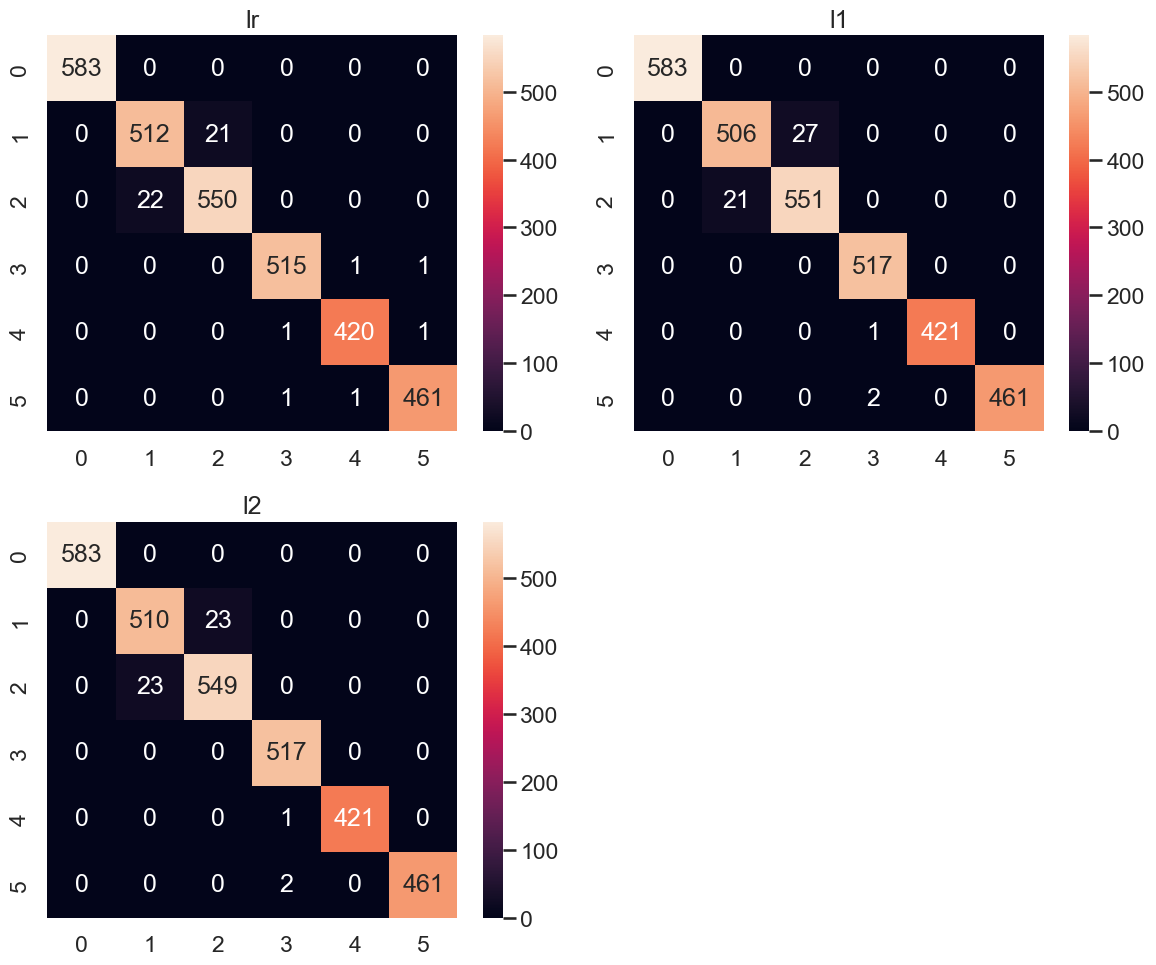

In [29]:
fig, axList = plt.subplots(nrows=2, ncols=2)
axList = axList.flatten()
fig.set_size_inches(12, 10)

axList[-1].axis('off')

for ax,lab in zip(axList[:-1], coeff_labels):
    sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d');
    ax.set(title=lab);
    
plt.tight_layout()
plt.show()

The model got 583 out of 583 correct for Class 0.(laying)

In the lr model, it predicted 21 SITTING instances as STANDING, and 22 STANDING instances as SITTING.

The Reason: These are both "Static" activities. In both cases, the person isn't moving, so the accelerometer only feels gravity. Unless the phone's angle is significantly different when sitting in a chair vs. standing up, the math looks almost identical to the model.

The model is surprisingly good at telling the difference between Walking, Walking Upstairs, and Walking Downstairs.

This means the "Jerk" and "Frequency" features you used are very effective at capturing the different rhythmic patterns of climbing vs. descending.

lr (Standard): Has the cleanest diagonal (fewest total errors).

l1 (Lasso): Notice the number 27 in the Class 1 row? L1 had a slightly harder time with Sitting/Standing. This is because by throwing away some "noisy" features to stay simple, it lost a tiny bit of the signal that helps distinguish these two very similar poses.

l2 (Ridge): Looks almost identical to the standard model, confirming that the "signal" in this data is so strong that the Ridge penalty didn't need to change much.

In [30]:
import joblib

# Saving the model (lr_l2)
joblib.dump(lr_l2, 'activity_model.pkl')

# Save the LabelEncoder so the app knows 1 = 'Sitting', etc.
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [31]:
sample = X_test.head(10)
sample.to_csv('sample_data.csv', index=False)